# TraceLens — GRPO Training (Fast / Minimal)

**Model**: Qwen2.5-0.5B-Instruct (fast) 
**Algorithm**: GRPO with episode-level grader rewards  
**Task**: Hard backend incident diagnosis  
**Target runtime**: < 1 hour on A100 40GB

Key changes from full version:
- Smaller model (0.5B vs 4B) — same architecture, just faster
- 30 training steps × 4 episodes per step = 120 total rollouts
- Shorter context windows (1024 tokens) — still enough for the task
- Shorter completions (48 tokens) — actions are compact JSON
- All warning logs suppressed

In [1]:
# ─── Cell 1: Install dependencies ────────────────────────────────────────────
%uv pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
%uv pip install -q trl>=0.12 transformers>=4.45 accelerate bitsandbytes datasets requests matplotlib
%uv pip install -q aiohttp nest_asyncio
print('Done.')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Done.


In [2]:
# ─── Cell 2: Suppress all noisy logs BEFORE importing anything ───────────────
import warnings, logging, os

# Silence Python warnings (deprecation, future, user)
warnings.filterwarnings('ignore')

# Silence all transformers/trl/accelerate/unsloth loggers
for name in [
    'transformers', 'transformers.generation', 'transformers.modeling_utils',
    'transformers.tokenization_utils_base', 'transformers.generation.utils',
    'trl', 'trl.trainer', 'accelerate', 'unsloth', 'peft', 'bitsandbytes',
    'torch', 'huggingface_hub',
]:
    logging.getLogger(name).setLevel(logging.ERROR)

# Env vars that suppress lower-level C++ / CUDA / tokenizer warnings
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TRANSFORMERS_VERBOSITY']  = 'error'
os.environ['ACCELERATE_DISABLE_RICH'] = '1'
os.environ['TRL_USE_RICH']            = '0'

print('Logging configured.')

Logging configured.


In [ ]:
# ─── Cell 3: Config ───────────────────────────────────────────────────────────
ENV_URL    = "https://sammyurfen-tracelens.hf.space"  # <-- your space URL
DIFFICULTY = "hard"

# ── Speed-optimised hyperparameters ───────────────────────────────────────────
NUM_STEPS  = 30   # 30 steps × 4 eps = 120 rollouts, ~25-35 min
GROUP_SIZE = 4    # smaller group, still enough for GRPO normalisation
LR         = 5e-6

# Context lengths — keep small so tokenisation + generation stay fast
MAX_PROMPT_LEN  = 1024  # incident prompts fit easily in 1024
MAX_COMP_LEN    = 48    # actions are short JSON (<40 tokens typically)
MAX_SEQ_LEN     = MAX_PROMPT_LEN + MAX_COMP_LEN  # 1072

# ── Model selection ───────────────────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    # 0.5B fits in fp16 on any GPU ≥ 4GB; 4-bit only for very small cards
    MODEL_NAME  = "Qwen/Qwen2.5-0.5B-Instruct"
    LOAD_IN_4BIT = vram_gb < 8
else:
    MODEL_NAME  = "Qwen/Qwen2.5-0.5B-Instruct"
    LOAD_IN_4BIT = True

print(f"Model : {MODEL_NAME}")
print(f"4-bit : {LOAD_IN_4BIT}")
if torch.cuda.is_available():
    print(f"VRAM  : {vram_gb:.1f} GB")
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

Model : Qwen/Qwen2.5-0.5B-Instruct
4-bit : False
VRAM  : 85.1 GB
GPU   : NVIDIA A100-SXM4-80GB


In [4]:
# ─── Cell 4: Load model ───────────────────────────────────────────────────────
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = MODEL_NAME,
    max_seq_length= MAX_SEQ_LEN,
    load_in_4bit  = LOAD_IN_4BIT,
)

model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    target_modules = ["q_proj", "v_proj", "k_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters : {total:,}")
print(f"Trainable  : {trainable:,}  ({100*trainable/total:.2f}%)")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.56.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu129. CUDA: 8.0. CUDA Toolkit: 12.9. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

unsloth/Qwen2.5-0.5B-Instruct does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Parameters : 502,830,976
Trainable  : 8,798,208  (1.75%)


In [5]:
# ─── Cell 5: Environment client + prompt builder ──────────────────────────────
import json, re, requests
from typing import Dict, List, Optional

class EnvClient:
    def __init__(self, base_url):
        self.base_url = base_url.rstrip('/')
        self.session  = requests.Session()

    def reset(self, difficulty='hard', seed=None):
        payload = {'difficulty': difficulty}
        if seed is not None:
            payload['seed'] = seed
        return self.session.post(f'{self.base_url}/reset', json=payload, timeout=30).json()

    def step(self, session_id, action):
        return self.session.post(f'{self.base_url}/step',
            json={'session_id': session_id, 'action': action}, timeout=30).json()

    def grade(self, seed, difficulty, service, root_cause, severity):
        try:
            r = self.session.post(f'{self.base_url}/grader', timeout=30,
                json={'seed': seed, 'difficulty': difficulty, 'service': service,
                      'root_cause': root_cause, 'severity': severity})
            return float(r.json().get('score', 0.0))
        except:
            return 0.0


SYSTEM_PROMPT = """You are an expert SRE diagnosing a backend incident.
You will inspect logs and metrics to identify the root cause.

TOOLS:
- open_logs(service): opens newest 3-line log window for a service
- scroll_logs(): reads OLDER logs for the currently open service (irreversible!)
- view_metrics(service): shows current metrics
- submit_diagnosis(service, root_cause, severity): finalize your diagnosis

CRITICAL RULES:
1. scroll_logs() continues reading the CURRENTLY OPEN service logs — going backward in time
2. Switching service with open_logs() loses your place in the previous service's logs
3. Once scrolled, you CANNOT go back — remember everything you read
4. Explore at least 2 services before submitting
5. Output ONE action as JSON. Nothing else.

OUTPUT FORMAT:
{\"type\": \"open_logs\", \"service\": \"<n>\"}
{\"type\": \"scroll_logs\"}
{\"type\": \"view_metrics\", \"service\": \"<n>\"}
{\"type\": \"submit_diagnosis\", \"service\": \"<n>\", \"root_cause\": \"<CAUSE>\", \"severity\": \"<low|medium|high>\"}"""


def build_prompt(alert, services, options, history, obs, tools, open_svc):
    lines = [SYSTEM_PROMPT, '']
    lines.append(f'ALERT: {alert}')
    lines.append(f'Services: {", ".join(services)}')
    lines.append(f'Valid root causes: {", ".join(options)}')
    lines.append(f'Tools: {", ".join(tools)}')
    if open_svc:
        lines.append(f'Currently open logs: {open_svc}')
    lines.append('')
    if history:
        lines.append('EVIDENCE FOUND SO FAR:')
        sigs = {}
        for h in history:
            if h.get('signal') and h.get('service'):
                sigs.setdefault(h['service'], []).append(h['signal'])
        for svc, ss in sigs.items():
            lines.append(f'  {svc}: ' + ' | '.join(list(dict.fromkeys(ss))[:4]))
        lines.append('')
        lines.append('RECENT STEPS:')
        for h in history[-3:]:
            lines.append(f'  Action: {h.get("action_str", "")}')
            lines.append(f'  Obs: {h.get("obs_preview", "")[:150]}')
        lines.append('')
    lines.append(f'CURRENT OBSERVATION:\n{obs}')
    lines.append('\nYour next action (JSON only):')
    return '\n'.join(lines)


def parse_action(text):
    for m in reversed(re.findall(r'\{[^{}]+\}', text)):
        try:
            obj = json.loads(m)
            if 'type' in obj:
                if obj['type'] == 'scroll':
                    obj['type'] = 'scroll_logs'
                if obj['type'] in {'open_logs', 'view_metrics', 'scroll_logs', 'submit_diagnosis'}:
                    return obj
        except:
            continue
    return None


def extract_signals(msg):
    sigs = []
    for line in msg.splitlines():
        l = line.strip().lower()
        if any(k in l for k in ['error','fail','timeout','crash','saturat','spiking','100%','maxed','degraded','stale']):
            sigs.append(line.strip()[:120])
        elif ':' in line:
            k, _, v = line.partition(':')
            if v.strip().lower() in {'high','spiking','100%','maxed','degraded'}:
                sigs.append(line.strip()[:120])
    return sigs


env = EnvClient(ENV_URL)
print('Environment client ready.')

Environment client ready.


In [6]:
# ─── Cell 6: Batched parallel episode runner ──────────────────────────────────
import asyncio, aiohttp, torch
import numpy as np


class AsyncEnvClient:
    def __init__(self, base_url):
        self.base_url = base_url.rstrip('/')

    async def reset(self, session, difficulty='hard', seed=None):
        payload = {'difficulty': difficulty}
        if seed is not None:
            payload['seed'] = seed
        async with session.post(f'{self.base_url}/reset', json=payload,
                                timeout=aiohttp.ClientTimeout(total=30)) as r:
            return await r.json()

    async def step(self, session, session_id, action):
        async with session.post(f'{self.base_url}/step',
                                json={'session_id': session_id, 'action': action},
                                timeout=aiohttp.ClientTimeout(total=30)) as r:
            return await r.json()

    async def grade(self, session, seed, difficulty, service, root_cause, severity):
        try:
            async with session.post(f'{self.base_url}/grader',
                                    json={'seed': seed, 'difficulty': difficulty,
                                          'service': service, 'root_cause': root_cause,
                                          'severity': severity},
                                    timeout=aiohttp.ClientTimeout(total=30)) as r:
                return float((await r.json()).get('score', 0.0))
        except:
            return 0.0


async_env = AsyncEnvClient(ENV_URL)


async def run_episodes_batched(model, tokenizer, env_client, seeds,
                               difficulty='hard', max_steps=14, greedy=False):
    """
    Runs len(seeds) episodes in parallel.
    All HTTP calls fire concurrently; all active episodes share one generate() call.
    """
    async with aiohttp.ClientSession() as session:

        # 1. Reset all episodes in parallel
        resets = await asyncio.gather(*[
            env_client.reset(session, difficulty=difficulty, seed=s) for s in seeds
        ])

        states = []
        for seed, data in zip(seeds, resets):
            obs = data['observation']
            states.append({
                'seed':         seed,
                'sid':          data['session_id'],
                'alert':        obs['message'],
                'services':     obs.get('available_services', []),
                'options':      obs.get('diagnosis_options', []),
                'tools':        obs.get('available_tools', ['open_logs', 'view_metrics']),
                'cur_obs':      obs['message'],
                'history':      [],
                'steps':        [],
                'step_rews':    [],
                'open_svc':     None,
                'final_action': None,
                'done':         False,
            })

        # 2. Step all active episodes together each timestep
        for _ in range(max_steps):
            active = [s for s in states if not s['done']]
            if not active:
                break

            prompts = [
                build_prompt(s['alert'], s['services'], s['options'],
                             s['history'], s['cur_obs'], s['tools'], s['open_svc'])
                for s in active
            ]

            tokenizer.padding_side = 'left'
            enc = tokenizer(
                prompts,
                return_tensors='pt',
                padding=True,
                truncation=True,
                max_length=MAX_PROMPT_LEN,
            ).to(model.device)

            # Unpadded prompt lengths for later slicing
            prompt_lens = [
                tokenizer(p, return_tensors='pt',
                          truncation=True, max_length=MAX_PROMPT_LEN)['input_ids'].shape[1]
                for p in prompts
            ]

            # Single batched generate — max_new_tokens only, NO max_length
            # (mixing both triggers a verbose warning that buries useful logs)
            with torch.no_grad():
                out = model.generate(
                    **enc,
                    max_new_tokens          = MAX_COMP_LEN,
                    do_sample               = not greedy,
                    temperature             = 0.8 if not greedy else 1.0,
                    pad_token_id            = tokenizer.eos_token_id,
                    # Suppress 'Setting pad_token_id ...' info log
                )

            padded_len = enc['input_ids'].shape[1]
            completions = [
                tokenizer.decode(out[j][padded_len:], skip_special_tokens=True).strip()
                for j in range(len(active))
            ]

            # Parse & fix up actions
            actions = []
            for j, (s, comp) in enumerate(zip(active, completions)):
                action = parse_action(comp)
                if action is None:
                    action = ({'type': 'scroll_logs'} if s['open_svc']
                              else {'type': 'open_logs', 'service': s['services'][0]})
                    completions[j] = json.dumps(action)
                if action['type'] == 'open_logs':
                    s['open_svc'] = action.get('service')
                if action['type'] == 'scroll_logs' and not s['open_svc']:
                    action = {'type': 'open_logs', 'service': s['services'][0]}
                    s['open_svc'] = s['services'][0]
                    completions[j] = json.dumps(action)
                actions.append(action)

            # All env.step() calls fire concurrently
            step_results = await asyncio.gather(*[
                env_client.step(session, s['sid'], a)
                for s, a in zip(active, actions)
            ], return_exceptions=True)

            for i, (s, action, comp, p_len, res) in enumerate(
                    zip(active, actions, completions, prompt_lens, step_results)):
                if isinstance(res, Exception):
                    s['done'] = True
                    continue
                new_obs = res['observation']
                r       = float(res.get('reward', 0.0))
                done    = res.get('done', False)
                msg     = new_obs.get('message', '')
                sigs    = extract_signals(msg)

                s['steps'].append({
                    'prompt':     prompts[i],
                    'completion': comp,
                    'prompt_len': p_len,
                    'action':     action,
                    'reward':     r,
                })
                s['step_rews'].append(r)
                s['history'].append({
                    'action_str':  json.dumps(action),
                    'obs_preview': msg[:300],
                    'service':     action.get('service') or s['open_svc'],
                    'signal':      sigs[0] if sigs else None,
                })
                s['history'] = s['history'][-12:]

                if done or action['type'] == 'submit_diagnosis':
                    s['final_action'] = action
                    s['done'] = True
                else:
                    s['cur_obs'] = msg
                    s['tools']   = new_obs.get('available_tools', s['tools'])

        # 3. Grade all finished episodes in parallel
        async def _grade(s):
            fa = s.get('final_action')
            if fa and fa.get('type') == 'submit_diagnosis':
                return await env_client.grade(
                    session, s['seed'], difficulty,
                    fa.get('service', ''), fa.get('root_cause', ''), fa.get('severity', 'high')
                )
            return 0.0

        grader_scores = await asyncio.gather(*[_grade(s) for s in states])

        results = []
        for s, grader in zip(states, grader_scores):
            pos_step = sum(max(0, r) for r in s['step_rews'])
            combined = 0.85 * grader + 0.15 * min(1.0, pos_step / 1.4)
            results.append((s['steps'], grader, combined, s.get('final_action')))
        return results


def collect_group(model, tokenizer, seeds, difficulty='hard'):
    """Sync wrapper — works inside Jupyter via nest_asyncio."""
    try:
        import nest_asyncio; nest_asyncio.apply()
    except ImportError:
        pass
    return asyncio.run(
        run_episodes_batched(model, tokenizer, async_env, seeds, difficulty)
    )


print('Batched episode runner ready.')

Batched episode runner ready.


In [7]:
# ─── Cell 7: Baseline evaluation (BEFORE training) ────────────────────────────
import asyncio
import numpy as np

try:
    import nest_asyncio; nest_asyncio.apply()
except ImportError:
    pass

print('Running BASELINE evaluation (greedy, 10 seeds in parallel)...')
eval_seeds = list(range(10))

baseline_results = asyncio.run(
    run_episodes_batched(model, tokenizer, async_env, eval_seeds,
                         difficulty=DIFFICULTY, max_steps=14, greedy=True)
)

baseline_scores = []
for seed, (_, grader, _, fa) in zip(eval_seeds, baseline_results):
    baseline_scores.append(grader)
    print(f'  seed={seed}  grader={grader:.3f}  action={fa}')

print(f'\nBASELINE avg grader: {np.mean(baseline_scores):.4f} '
      f'\u00b1 {np.std(baseline_scores):.4f}')

Running BASELINE evaluation (greedy, 10 seeds in parallel)...
  seed=0  grader=0.010  action={'type': 'submit_diagnosis', 'service': 'sessions-api', 'root_cause': 'unexpected latency spike in request handler', 'severity': 'high'}
  seed=1  grader=0.600  action={'type': 'submit_diagnosis', 'service': 'session-edge', 'root_cause': 'AUTH_FAILURE', 'severity': 'low'}
  seed=2  grader=0.010  action={'type': 'submit_diagnosis', 'service': 'gateway', 'root_cause': 'timeout connecting to upstream dependency', 'severity': 'low'}
  seed=3  grader=0.990  action={'type': 'submit_diagnosis', 'service': 'profile-worker', 'root_cause': 'SERVICE_CRASH', 'severity': 'high'}
  seed=4  grader=0.990  action={'type': 'submit_diagnosis', 'service': 'profile-worker', 'root_cause': 'SERVICE_CRASH', 'severity': 'high'}
  seed=5  grader=0.600  action={'type': 'submit_diagnosis', 'service': 'orchestrator', 'root_cause': 'TIMEOUT', 'severity': 'low'}
  seed=6  grader=0.600  action={'type': 'submit_diagnosis', 'se

In [8]:
# ─── Cell 8: GRPO training loop ───────────────────────────────────────────────
import torch.nn.functional as F
import time

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=0.01
)
KL_COEFF = 0.05
CLIP_EPS = 0.2
train_log = []

t_start = time.time()

for step in range(NUM_STEPS):
    model.train()

    # Collect all GROUP_SIZE episodes in parallel
    seeds   = [step * GROUP_SIZE + i for i in range(GROUP_SIZE)]
    results = collect_group(model, tokenizer, seeds)

    all_steps = [r[0] for r in results]
    rewards   = [r[2] for r in results]

    rewards_t  = torch.tensor(rewards, dtype=torch.float32)
    advantages = (
        (rewards_t - rewards_t.mean()) / (rewards_t.std() + 1e-8)
        if rewards_t.std() > 1e-8
        else rewards_t - rewards_t.mean()
    )

    # GRPO loss
    total_loss = torch.tensor(0.0, device=model.device)
    total_kl   = 0.0
    valid      = 0

    for ep_idx, ep_steps in enumerate(all_steps):
        adv = advantages[ep_idx].item()
        for s in ep_steps:
            # Tokenize prompt and completion separately to get exact boundary
            prompt_ids = tokenizer(
                s['prompt'],
                return_tensors='pt',
                truncation=True,
                max_length=MAX_PROMPT_LEN,
            )['input_ids'].to(model.device)

            comp_ids = tokenizer(
                s['completion'],
                return_tensors='pt',
                add_special_tokens=False,
                truncation=True,
                max_length=MAX_COMP_LEN,
            )['input_ids'].to(model.device)

            full_ids = torch.cat([prompt_ids, comp_ids], dim=1)
            enc      = {
                'input_ids':      full_ids,
                'attention_mask': torch.ones_like(full_ids),
            }
            p_len   = prompt_ids.shape[1]
            seq_len = full_ids.shape[1]
            if p_len >= seq_len - 1:
                continue  # completion was empty or fully truncated

            logits = model(**enc).logits[0, p_len-1:-1]
            cids   = full_ids[0, p_len:]
            lp     = F.log_softmax(logits, dim=-1).gather(1, cids.unsqueeze(1)).squeeze(1)

            with torch.no_grad(), model.disable_adapter():
                ref_logits = model(**enc).logits[0, p_len-1:-1]
                ref_lp     = F.log_softmax(ref_logits, dim=-1).gather(1, cids.unsqueeze(1)).squeeze(1)

            kl      = (lp - ref_lp).sum()
            ratio   = torch.exp(lp.sum() - ref_lp.sum().detach())
            clipped = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS)
            loss    = -torch.min(ratio * adv, clipped * adv) + KL_COEFF * kl

            total_loss = total_loss + loss
            total_kl  += kl.item()
            valid     += 1

    if valid > 0:
        (total_loss / valid).backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0
        )
        optimizer.step()
        optimizer.zero_grad()

    elapsed = (time.time() - t_start) / 60
    eta     = elapsed / (step + 1) * (NUM_STEPS - step - 1)

    log_entry = {
        'step':        step + 1,
        'mean_reward': float(rewards_t.mean()),
        'mean_grader': float(np.mean([results[i][1] for i in range(len(results))])),
        'grpo_loss':   float(total_loss.item() / max(valid, 1)),
        'mean_kl':     total_kl / max(valid, 1),
    }
    train_log.append(log_entry)

    # Print every step (only 30 total)
    print(f"Step {step+1:3d}/{NUM_STEPS}  "
          f"reward={log_entry['mean_reward']:.4f}  "
          f"grader={log_entry['mean_grader']:.4f}  "
          f"loss={log_entry['grpo_loss']:.4f}  "
          f"elapsed={elapsed:.1f}m  eta={eta:.1f}m")

print('\nTraining complete!')

Step   1/30  reward=0.0505  grader=0.0550  loss=-0.2891  elapsed=0.2m  eta=6.7m
Step   2/30  reward=0.3684  grader=0.4025  loss=0.2383  elapsed=0.4m  eta=5.2m
Step   3/30  reward=0.3285  grader=0.3550  loss=-0.1664  elapsed=0.5m  eta=4.5m
Step   4/30  reward=0.1661  grader=0.1800  loss=0.1479  elapsed=0.7m  eta=4.8m
Step   5/30  reward=0.3132  grader=0.3275  loss=-0.0063  elapsed=0.9m  eta=4.5m
Step   6/30  reward=0.1933  grader=0.2025  loss=-0.0427  elapsed=1.1m  eta=4.5m
Step   7/30  reward=0.2108  grader=0.2275  loss=-0.1647  elapsed=1.3m  eta=4.3m
Step   8/30  reward=0.2336  grader=0.2550  loss=0.1531  elapsed=1.5m  eta=4.1m
Step   9/30  reward=0.3326  grader=0.3525  loss=-0.0954  elapsed=1.7m  eta=3.9m
Step  10/30  reward=0.0524  grader=0.0550  loss=-0.1267  elapsed=1.8m  eta=3.7m
Step  11/30  reward=0.2154  grader=0.2250  loss=0.0662  elapsed=2.0m  eta=3.5m
Step  12/30  reward=0.3374  grader=0.3525  loss=0.2411  elapsed=2.3m  eta=3.4m
Step  13/30  reward=0.3326  grader=0.3525  lo

In [9]:
# ─── Cell 9: After-training evaluation ───────────────────────────────────────
print('Running POST-TRAINING evaluation (greedy, 10 seeds in parallel)...')

after_results = asyncio.run(
    run_episodes_batched(model, tokenizer, async_env, eval_seeds,
                         difficulty=DIFFICULTY, max_steps=14, greedy=True)
)

after_scores = []
for seed, (_, grader, _, fa) in zip(eval_seeds, after_results):
    after_scores.append(grader)
    print(f'  seed={seed}  grader={grader:.3f}  action={fa}')

print(f'\nBEFORE: {np.mean(baseline_scores):.4f} \u00b1 {np.std(baseline_scores):.4f}')
print(f'AFTER:  {np.mean(after_scores):.4f} \u00b1 {np.std(after_scores):.4f}')
print(f'DELTA:  {np.mean(after_scores) - np.mean(baseline_scores):+.4f}')

Running POST-TRAINING evaluation (greedy, 10 seeds in parallel)...
  seed=0  grader=0.010  action={'type': 'submit_diagnosis', 'service': 'sessions-api', 'root_cause': 'unexpected latency spike in request handler', 'severity': 'high'}
  seed=1  grader=0.600  action={'type': 'submit_diagnosis', 'service': 'session-edge', 'root_cause': 'AUTH_FAILURE', 'severity': 'low'}
  seed=2  grader=0.700  action={'type': 'submit_diagnosis', 'service': 'gateway', 'root_cause': 'DB_OVERLOAD', 'severity': 'high'}
  seed=3  grader=0.990  action={'type': 'submit_diagnosis', 'service': 'profile-worker', 'root_cause': 'SERVICE_CRASH', 'severity': 'high'}
  seed=4  grader=0.990  action={'type': 'submit_diagnosis', 'service': 'profile-worker', 'root_cause': 'SERVICE_CRASH', 'severity': 'high'}
  seed=5  grader=0.600  action={'type': 'submit_diagnosis', 'service': 'orchestrator', 'root_cause': 'TIMEOUT', 'severity': 'low'}
  seed=6  grader=0.600  action={'type': 'submit_diagnosis', 'service': 'search-api', 'r

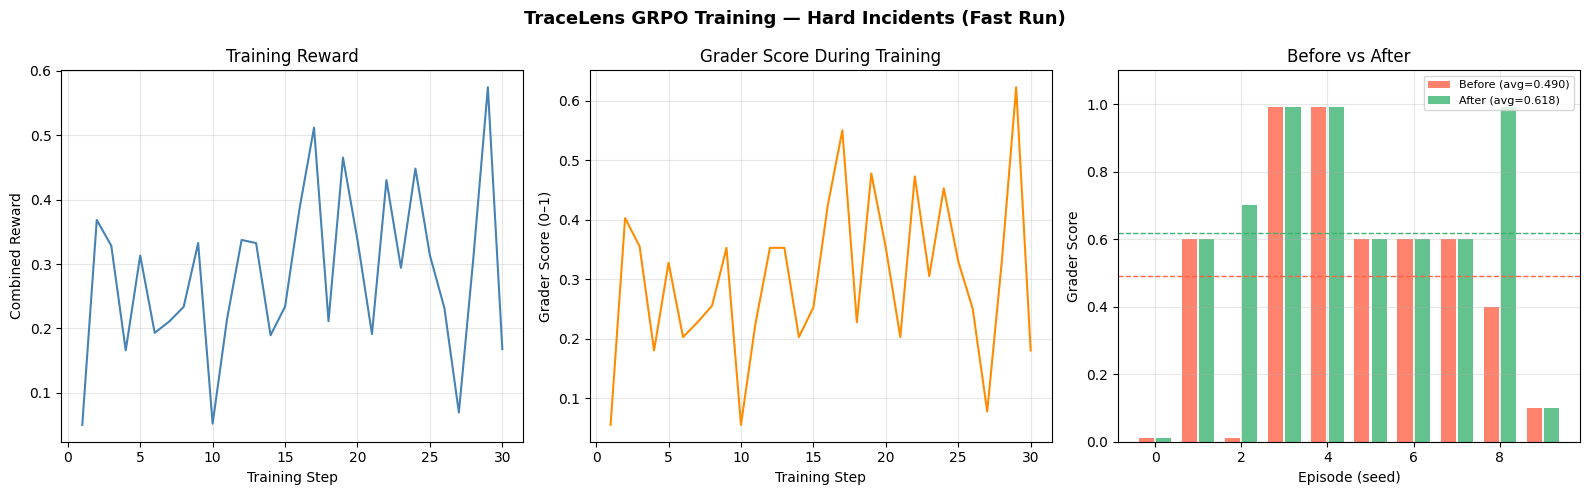

Plot saved to tracelens_results_fast.png


In [10]:
# ─── Cell 10: Plots ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TraceLens GRPO Training — Hard Incidents (Fast Run)',
             fontsize=13, fontweight='bold')

steps = [d['step'] for d in train_log]

axes[0].plot(steps, [d['mean_reward'] for d in train_log], color='steelblue')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Combined Reward')
axes[0].set_title('Training Reward')
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, [d['mean_grader'] for d in train_log], color='darkorange')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Grader Score (0\u20131)')
axes[1].set_title('Grader Score During Training')
axes[1].grid(True, alpha=0.3)

x = range(10)
axes[2].bar([i - 0.2 for i in x], baseline_scores, 0.35,
            label=f'Before (avg={np.mean(baseline_scores):.3f})',
            color='tomato', alpha=0.8)
axes[2].bar([i + 0.2 for i in x], after_scores, 0.35,
            label=f'After (avg={np.mean(after_scores):.3f})',
            color='mediumseagreen', alpha=0.8)
axes[2].axhline(np.mean(baseline_scores), color='tomato',        linestyle='--', linewidth=1)
axes[2].axhline(np.mean(after_scores),    color='mediumseagreen', linestyle='--', linewidth=1)
axes[2].set_xlabel('Episode (seed)')
axes[2].set_ylabel('Grader Score')
axes[2].set_title('Before vs After')
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 1.1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tracelens_results_fast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to tracelens_results_fast.png')

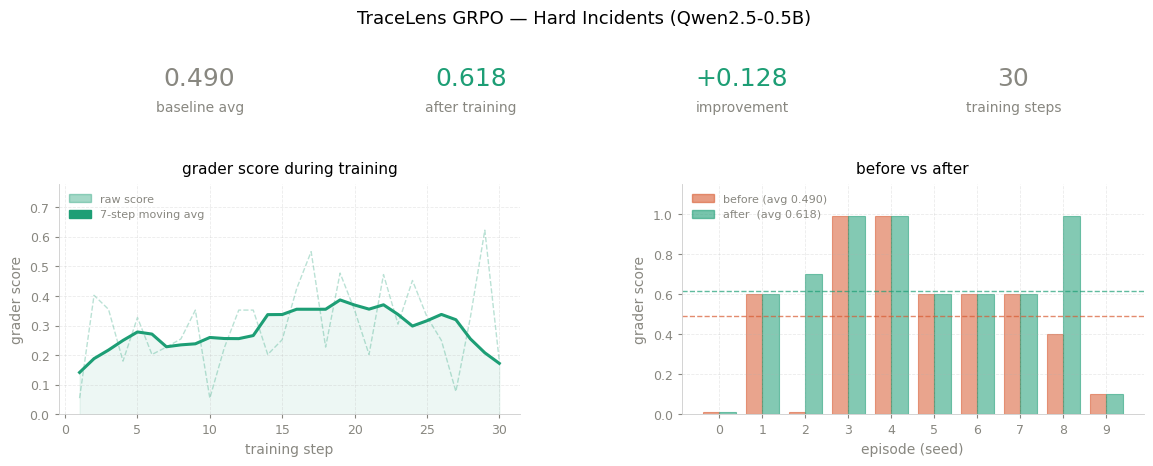

Saved to tracelens_results_polished.png


In [12]:
# ─── Cell: Polished plots ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def moving_average(arr, w=7):
    return np.convolve(arr, np.ones(w)/w, mode='same')

# ── Pull data from training run ───────────────────────────────────────────────
steps         = [d['step'] for d in train_log]
raw_grader    = [d['mean_grader'] for d in train_log]
smoothed      = moving_average(raw_grader, w=7)

before = np.array(baseline_scores)
after  = np.array(after_scores)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.6,
    'axes.linewidth':    0.6,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
})

TEAL   = '#1D9E75'
TEAL_L = '#9FE1CB'
CORAL  = '#D85A30'
CORAL_L= '#F5C4B3'
GRAY   = '#888780'

fig = plt.figure(figsize=(14, 4.5))
fig.suptitle('TraceLens GRPO — Hard Incidents (Qwen2.5-0.5B)', fontsize=13, fontweight='normal', y=1.01)

# ── Metric summary bar across top ────────────────────────────────────────────
gs = fig.add_gridspec(2, 2, height_ratios=[0.18, 1], hspace=0.55, wspace=0.35)

ax_meta = fig.add_subplot(gs[0, :])
ax_meta.axis('off')
metrics = [
    ('baseline avg',  f'{np.mean(before):.3f}', GRAY),
    ('after training',f'{np.mean(after):.3f}',  TEAL),
    ('improvement',   f'+{np.mean(after)-np.mean(before):.3f}', TEAL),
    ('training steps',f'{len(steps)}',           GRAY),
]
for i, (label, val, col) in enumerate(metrics):
    x = 0.13 + i * 0.25
    ax_meta.text(x, 0.75, val,   transform=ax_meta.transAxes,
                 ha='center', va='center', fontsize=18, fontweight='normal', color=col)
    ax_meta.text(x, 0.05, label, transform=ax_meta.transAxes,
                 ha='center', va='center', fontsize=10, color=GRAY)

# ── Left: grader score over training ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])

ax1.plot(steps, raw_grader, color=TEAL, alpha=0.3, linewidth=1,
         linestyle='--', label='raw score')
ax1.plot(steps, smoothed,   color=TEAL, linewidth=2.2, label='7-step moving avg')
ax1.fill_between(steps, smoothed, alpha=0.08, color=TEAL)

ax1.set_xlabel('training step', fontsize=10, color=GRAY)
ax1.set_ylabel('grader score', fontsize=10, color=GRAY)
ax1.set_title('grader score during training', fontsize=11, pad=8)
ax1.set_ylim(0, max(raw_grader) * 1.25)
ax1.tick_params(colors=GRAY, labelsize=9)
ax1.spines['bottom'].set_color('#ccc')
ax1.spines['left'].set_color('#ccc')

raw_patch  = mpatches.Patch(color=TEAL, alpha=0.4, label='raw score')
avg_patch  = mpatches.Patch(color=TEAL,             label='7-step moving avg')
ax1.legend(handles=[raw_patch, avg_patch], fontsize=8, frameon=False,
           loc='upper left', labelcolor=GRAY)

# ── Right: before vs after per episode ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])

x      = np.arange(len(before))
width  = 0.38

bars_b = ax2.bar(x - width/2, before, width, color=CORAL,  alpha=0.55,
                 label=f'before (avg {np.mean(before):.3f})')
bars_a = ax2.bar(x + width/2, after,  width, color=TEAL,   alpha=0.55,
                 label=f'after  (avg {np.mean(after):.3f})')

# Edge color
for bar in bars_b:
    bar.set_edgecolor(CORAL); bar.set_linewidth(0.8)
for bar in bars_a:
    bar.set_edgecolor(TEAL);  bar.set_linewidth(0.8)

ax2.axhline(np.mean(before), color=CORAL, linestyle='--', linewidth=1.0, alpha=0.7)
ax2.axhline(np.mean(after),  color=TEAL,  linestyle='--', linewidth=1.0, alpha=0.7)

ax2.set_xlabel('episode (seed)', fontsize=10, color=GRAY)
ax2.set_ylabel('grader score',   fontsize=10, color=GRAY)
ax2.set_title('before vs after', fontsize=11, pad=8)
ax2.set_xticks(x)
ax2.set_xticklabels([str(i) for i in range(len(before))], fontsize=9)
ax2.set_ylim(0, 1.15)
ax2.tick_params(colors=GRAY, labelsize=9)
ax2.spines['bottom'].set_color('#ccc')
ax2.spines['left'].set_color('#ccc')

b_patch = mpatches.Patch(color=CORAL, alpha=0.6, label=f'before (avg {np.mean(before):.3f})')
a_patch = mpatches.Patch(color=TEAL,  alpha=0.6, label=f'after  (avg {np.mean(after):.3f})')
ax2.legend(handles=[b_patch, a_patch], fontsize=8, frameon=False,
           loc='upper left', labelcolor=GRAY)

plt.savefig('tracelens_results_polished.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved to tracelens_results_polished.png')

In [11]:
# ─── Cell 11: Save model ──────────────────────────────────────────────────────
model.save_pretrained('./tracelens_qwen05b_grpo')
tokenizer.save_pretrained('./tracelens_qwen05b_grpo')
print('Model saved to ./tracelens_qwen05b_grpo')

# Optional: push to HuggingFace Hub
# from huggingface_hub import notebook_login
# notebook_login()
# model.push_to_hub('your-username/tracelens-qwen05b-grpo')

Model saved to ./tracelens_qwen05b_grpo
